# Train a diffusion model with Dew

[Notebook 01](01-diffusion-from-scratch.ipynb) builds a diffusion model by hand: the noise schedule, the loss, the network and the samplers. This notebook trains the same kind of model with Dew, where each of those pieces already exists. We train a small diffusion transformer on Oxford Flowers at 64x64, look at the loss, generate flowers from pure noise, and reload the trained weights from the checkpoint.

The notebook expects one NVIDIA GPU. On an RTX 4080 shared with other jobs the whole notebook took about twenty minutes, most of it training.

## Install

This installs Dew from GitHub, the CUDA build of JAX, and Hugging Face `datasets` (the `streaming` extra), which downloads the flower images.

In [1]:
%pip install -q "dew-ml[streaming] @ git+https://github.com/AshishKumar4/dew" "jax[cuda12]"

Note: you may need to restart the kernel to use updated packages.


## Settings

Every number this notebook uses lives here, so you can change the run in one place. The images are 64x64, a batch holds 64 of them, and we train for 6,000 steps.

In [2]:
import os

IMAGE_SIZE = 64
BATCH_SIZE = 64
STEPS = 6000
LEARNING_RATE = 3e-4
SAMPLE_STEPS = 40
RUN_DIR = "runs/02-diffusion"
SEED = 0

# The tutorial test sets DEW_TUTORIAL_SMOKE=1 to run every cell in minutes on a CPU.
if os.environ.get("DEW_TUTORIAL_SMOKE") == "1":
    BATCH_SIZE, STEPS, SAMPLE_STEPS = 8, 4, 4


In [3]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

print(jax.devices())

[CudaDevice(id=0)]


A small helper to draw a batch of images in a grid. Dew keeps images as uint8 in `[0, 255]` when they come from the data, and the model works in `[-1, 1]`, so the helper accepts both.

In [4]:
from dew.artifacts import uint8_pixels

def show_images(images, columns=8, title=None):
    images = np.asarray(images)
    if images.dtype != np.uint8:
        images = uint8_pixels(images)
    rows = (len(images) + columns - 1) // columns
    figure, axes = plt.subplots(rows, columns, figsize=(columns * 1.2, rows * 1.2))
    for axis in np.ravel(axes):
        axis.axis("off")
    for axis, image in zip(np.ravel(axes), images):
        axis.imshow(image)
    if title:
        figure.suptitle(title)
    plt.show()

## The data

Oxford Flowers has about 8,000 photos of 102 kinds of flower. We read a copy from the Hugging Face Hub, `pranked03/flowers-blip-captions`, which also carries a caption for every photo; notebook 03 uses those captions.

`HFImages` describes the dataset: where it lives, the image size, and how to read it. `load(batch=...)` turns that description into a `Dataset`, whose `train()` returns an endless, shuffled stream of batches. Each record is resized to 64x64 and randomly flipped. `Loading(workers=0, threads=16)` reads records with 16 threads inside this process, which is plenty for images this small. The first run downloads about 270 MB.

In [5]:
from dew.data import DataPartition, HFImages, Loading

data = HFImages(
    name="pranked03/flowers-blip-captions",
    image_size=IMAGE_SIZE,
    val_batches=0,
    loading=Loading(workers=0, threads=16, read_buffer=64),
).load(batch=BATCH_SIZE)

print(data.records, "images,", data.steps_per_epoch, "steps per epoch")

6552 images, 102 steps per epoch


(64, 64, 64, 3) uint8


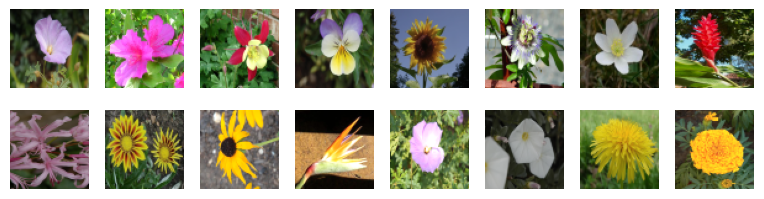

In [6]:
batch = next(iter(data.train(DataPartition())))
print(batch["image"].shape, batch["image"].dtype)
show_images(batch["image"][:16])

## The noise process

A diffusion model learns to undo noise. During training we take a clean image $x_0$, pick a noise level $\sigma$, and make a noisy image

$x_t = \alpha_t x_0 + \sigma_t \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$

The model sees $x_t$ and the noise level and has to recover the clean image. Sampling starts from pure noise at the highest level and removes it a little at a time.

Dew calls this pairing of a noise schedule, what the network predicts and how the loss is weighted a `Process`. The `EDM` preset follows Karras et al. (2022): $\alpha_t$ stays at 1, $\sigma$ goes from 0.002 to 80, training draws noise levels from a log-normal distribution, and sampling walks the levels on a grid that spends more steps at low noise. `presets.EDM()` is the configuration, and calling it builds the `Process`.

In [7]:
from dew import presets

process = presets.EDM()()
schedule = process.sampler_schedule

times = process.times(8)
alphas, sigmas = schedule.rates(times)
print("sampling times:", np.round(np.asarray(times), 3))
print("alpha:", np.round(np.asarray(alphas), 3))
print("sigma:", np.round(np.asarray(sigmas), 3))

sampling times: [1.    0.857 0.714 0.571 0.429 0.286 0.143 0.   ]
alpha: [1. 1. 1. 1. 1. 1. 1. 1.]
sigma: [8.0000e+01 3.4992e+01 1.3699e+01 4.6370e+00 1.2870e+00 2.6700e-01
 3.5000e-02 2.0000e-03]


Here is one flower at each of those eight noise levels, from the most noise on the left to the least on the right. The images are clipped to `[-1, 1]` for display, so the leftmost ones look like plain static.

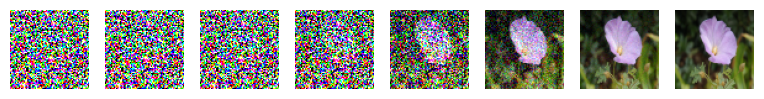

In [8]:
image = batch["image"][0].astype(np.float32) / 127.5 - 1
noise = jax.random.normal(jax.random.key(SEED), image.shape)
noisy = [alpha * image + sigma * noise for alpha, sigma in zip(alphas, sigmas)]
show_images(np.clip(np.stack(noisy), -1, 1), columns=8)

## The model

The network is a small diffusion transformer (DiT). It cuts the 64x64 image into 4x4 patches, which gives 256 tokens, runs them through six transformer layers, and returns one prediction per pixel. `models.build("simple_dit", ...)` looks the model up in Dew's registry by name. We compute in bfloat16, and `attention_impl="auto"` lets Dew pick the fastest attention kernel for the GPU.

`InputSpec(Field("image", (64, 64, 3)))` tells the objective which batch field to generate and its shape. This model has no conditions: it learns what flowers look like, but we cannot ask it for a particular one.

In [9]:
from dew import Field, InputSpec, models

model = models.build(
    "simple_dit",
    patch_size=4,
    emb_features=256,
    num_layers=6,
    num_heads=4,
    output_channels=3,
    dtype="bfloat16",
    attention_impl="auto",
)
inputs = InputSpec(Field("image", (IMAGE_SIZE, IMAGE_SIZE, 3)))

## The objective and the trainer

`DiffusionObjective` holds the diffusion loss: it draws a noise level for each image, makes the noisy image, runs the model and weights the error. It also asks the trainer to keep an exponential moving average (EMA) of the weights. The EMA copy changes slowly and usually gives cleaner samples than the live weights. `sampler`, `guidance` and `steps` say how the objective samples when it previews images; they do not change training.

`Trainer` does the rest: it computes gradients, applies the AdamW optimizer, updates the EMA, and writes checkpoints to `RUN_DIR`. `LocalTracker` records the logged numbers in a JSON file, which we plot after training.

In [10]:
import optax
from dew import Checkpoints, LocalTracker, Trainer
from dew.objectives.diffusion import DiffusionObjective
from dew.sampling import EulerAncestral

objective = DiffusionObjective(
    model, process, inputs,
    ema_decay=0.999,
    sampler=EulerAncestral(), guidance=None, steps=SAMPLE_STEPS,
)
tracker = LocalTracker(f"{RUN_DIR}/tracking")
trainer = Trainer(
    objective, optax.adamw(LEARNING_RATE),
    key=jax.random.key(SEED),
    checkpoints=Checkpoints(RUN_DIR),
    tracker=tracker,
)

variables = jax.eval_shape(objective.init, jax.random.key(0))
n_params = sum(x.size for x in jax.tree_util.tree_leaves(variables["params"]))
print(f"{n_params / 1e6:.1f}M parameters")

8.7M parameters


## Training

`fit` trains until the step counter reaches `STEPS`, prints the loss every `log_every` steps, and writes a checkpoint at the end. If `RUN_DIR` already holds a checkpoint, `fit` resumes from it, so running this cell twice does not train twice.

In [11]:
state = trainer.fit(data, steps=STEPS, log_every=500, checkpoint_every=STEPS)

Training from step 0 to 6000 on {'data': 1, 'expert': 1, 'fsdp': 1, 'tensor': 1, 'sequence': 1, 'stage': 1} (1 process(es))


step 500: loss 0.1288


step 1000: loss 0.1125


step 1500: loss 0.1207


step 2000: loss 0.1059


...

step 4500: loss 0.0957


step 5000: loss 0.1122


step 5500: loss 0.1097


step 6000: loss 0.0915


Goodput: first step after 53.08 s, 95.2% of the wall time in steps


The tracker wrote one line per log step to `scalars.jsonl`, here every 500 steps. The loss falls from about 0.13 to about 0.09 and jumps around on the way, because every batch draws new noise levels and some levels are much harder than others.

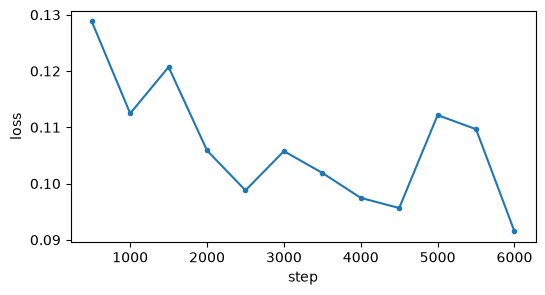

In [12]:
import json

rows = [json.loads(line) for line in open(f"{RUN_DIR}/tracking/scalars.jsonl")]
rows = [row for row in rows if "train/loss" in row["scalars"]]
plt.figure(figsize=(6, 3))
plt.plot([row["step"] for row in rows], [row["scalars"]["train/loss"] for row in rows], marker=".")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

## Sampling

To generate an image we run the noise process backwards. `process.noise` draws the starting point, pure noise with the spread of the highest noise level. `process.denoiser` wraps the model and its weights into the function a sampler calls: given a noisy image and its time, it returns the model's guess of the clean image and of the noise. `sample` then runs a solver over `SAMPLE_STEPS` noise levels in one compiled loop.

`state.averaged` is the weights tree with the EMA weights in place of the live ones. `objective.trainable` keeps only the model's own weights.

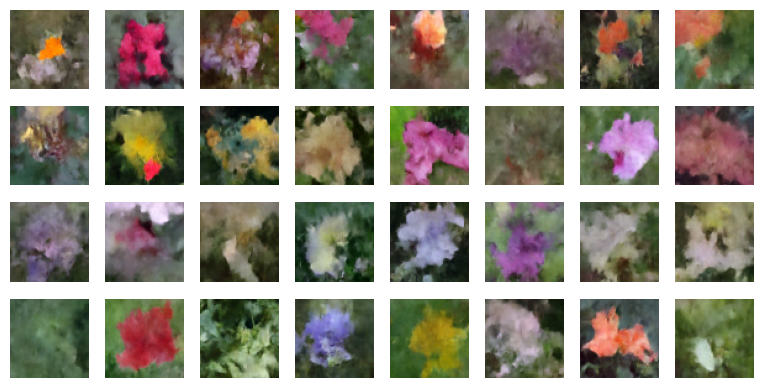

In [13]:
from dew.sampling import sample

def generate(params, count, key):
    denoise = process.denoiser(model, objective.trainable(params), {})
    x_T = process.noise(key, (count, IMAGE_SIZE, IMAGE_SIZE, 3))
    return sample(denoise, x_T, SAMPLE_STEPS, solver=EulerAncestral(), key=key)

images = generate(state.averaged, 32, jax.random.key(1))
show_images(images)

The flowers are soft and painterly, and a few are only blobs of colour. That is what 6,000 steps of a 9M-parameter model give; longer training and a bigger model sharpen them.

## Reloading the checkpoint

The checkpoint in `RUN_DIR` holds the arrays: weights, EMA, optimizer state and step counters. It does not hold the code. To reload, we build a new `Trainer` over the same objective and call `place()`, which restores the latest checkpoint onto the GPU. Sampling with the same key gives the same images, which shows the weights came back unchanged.

In [14]:
restored, _, _ = Trainer(
    objective, optax.adamw(LEARNING_RATE),
    key=jax.random.key(SEED),
    checkpoints=Checkpoints(RUN_DIR),
).place()
print("restored step:", int(restored.step))

again = generate(restored.averaged, 32, jax.random.key(1))
print("largest difference from the samples above:", float(jnp.max(jnp.abs(again - images))))

Resumed from step 6000 in /tmp/nbwork/run/runs/02-diffusion
restored step: 6000


largest difference from the samples above: 0.0


## Where to go next

[Notebook 03](03-text-to-image-with-guidance.ipynb) trains on the captions as well, so you can ask for a flower in words. [Notebook 04](04-samplers-and-schedules.ipynb) loads this notebook's checkpoint and compares Dew's samplers on it. `recipes/diffusion/train.py` runs the same kind of training from the command line.